In [1]:

import os
import numpy as np
import pandas as pd
import cv2
from google.colab import drive
import matplotlib.pyplot as plt
from PIL import Image
import time
import sys

# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:


# ---------------- IMPORTS ----------------
import shutil
import math
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ConvNeXtBase
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix


# ---------------- HYPERPARAMETERS ----------------
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
TRAIN_TEST_SPLIT = 0.8
LEARNING_RATE = 1e-4

# ---------------- PATHS (adapt if necessary) ----------------
classfall_path = "/content/drive/MyDrive/imgchuteclasse2"
classother_path = "/content/drive/MyDrive/imgautreclasse4"

# ---------------- PREPARATION OF A TEMPORARY DIRECTORY ----------------
base_dir = "/tmp/fall_classification"
os.makedirs(base_dir, exist_ok=True)

train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

train_fall = os.path.join(train_dir, "fall")
train_other = os.path.join(train_dir, "other")
test_fall = os.path.join(test_dir, "fall")
test_other = os.path.join(test_dir, "other")
for folder in [train_fall, train_other, test_fall, test_other]:
    os.makedirs(folder, exist_ok=True)

# ---------------- DATA ORGANIZATION FUNCTION ----------------
print("[INFO] Organizing data...")
from sklearn.model_selection import train_test_split

def organize_data(source_path, class_name):
    files = [f for f in os.listdir(source_path) if os.path.isfile(os.path.join(source_path, f))]
    train_files, test_files = train_test_split(files, train_size=TRAIN_TEST_SPLIT, random_state=42)
    for f in train_files:
        shutil.copy(os.path.join(source_path, f), os.path.join(train_dir, class_name, f))
    for f in test_files:
        shutil.copy(os.path.join(source_path, f), os.path.join(test_dir, class_name, f))

organize_data(classfall_path, "fall")
organize_data(classother_path, "other")

# ---------------- IMAGE GENERATORS ----------------
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# ---------------- MODEL CREATION FUNCTION ----------------
def create_enhanced_model(input_shape=(224, 224, 3)):
    # Pre-trained backbone
    backbone = ConvNeXtBase(include_top=False, weights='imagenet', input_shape=input_shape, pooling=None)
    backbone.trainable = False  # Initial freezing to avoid fine-tuning (and OOM)

    # Spatial attention module (CBAM-like)
    def spatial_attention(x):
        avg_pool = layers.Lambda(lambda t: tf.reduce_mean(t, axis=3, keepdims=True))(x)
        max_pool = layers.Lambda(lambda t: tf.reduce_max(t, axis=3, keepdims=True))(x)
        concat = layers.Concatenate(axis=3)([avg_pool, max_pool])
        cbam = layers.Conv2D(1, (7,7), padding='same', activation='sigmoid')(concat)
        return layers.Multiply()([x, cbam])

    inputs = layers.Input(shape=input_shape)
    x = backbone(inputs)
    x = spatial_attention(x)

    # Dynamic reshape into (batch, sequence_length, channels)
    x = layers.Lambda(lambda t: tf.reshape(t, (tf.shape(t)[0], -1, tf.shape(t)[-1])))(x)

    # Temporal branch (sequence simulation via frames)
    x = layers.Bidirectional(layers.GRU(128, return_sequences=True))(x)
    x = layers.Attention()([x, x])  # self-attention

    # Classification
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    return model

# ---------------- INITIALIZATION AND COMPILATION ----------------
model = create_enhanced_model(IMG_SIZE + (3,))

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auc'), tf.keras.metrics.Recall(name='recall'), 'accuracy']
)

model.summary()

# ---------------- CALLBACKS ----------------
callbacks = [
    EarlyStopping(patience=5, monitor='val_loss', restore_best_weights=True),
    ReduceLROnPlateau(factor=0.2, patience=2, monitor='val_loss')
]


[INFO] Organizing data...
Found 1082 images belonging to 2 classes.
Found 272 images belonging to 2 classes.


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base       │ (None, 7, 7,      │ 87,566,464 │ input_layer_5[0]… │
│ (Functional)        │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 7, 7, 1)   │          0 │ convnext_base[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 7, 7, 1)   │          0 │ convnext_base[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 7, 7, 2)   │          0 │ lambda[0][0],     │
│ (Concatenate)       │                   │            │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 7, 7, 1)   │         99 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 7, 7,      │          0 │ convnext_base[0]… │
│                     │ 1024)             │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, None,      │          0 │ multiply[0][0]    │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, None, 256) │    886,272 │ lambda_2[0][0]    │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, None, 256) │          0 │ bidirectional[0]… │
│ (Attention)         │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ attention[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │     65,792 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        257 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 88,518,884 (337.67 MB)

 Trainable params: 952,420 (3.63 MB)

 Non-trainable params: 87,566,464 (334.04 MB)

In [3]:

# ---------------- TRAINING (INITIAL TRAINING ONLY) ----------------
print("[INFO] Starting initial training...")
steps_per_epoch = math.ceil(train_generator.samples / BATCH_SIZE)
validation_steps = math.ceil(test_generator.samples / BATCH_SIZE)

history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    validation_data=test_generator,
    validation_steps=validation_steps,
    epochs=EPOCHS,
    callbacks=callbacks
)

# ---------------- EVALUATION ----------------
print("[INFO] Final evaluation...")
test_loss, test_auc, test_recall, test_acc = model.evaluate(test_generator, steps=validation_steps)
print(f"\nAccuracy on test set: {test_acc*100:.2f}%")
print(f"AUC: {test_auc*100:.2f}%")
print(f"Recall: {test_recall*100:.2f}%")


predictions = model.predict(test_generator, steps=validation_steps)
pred_classes = (predictions > 0.5).astype(int).flatten()
true_classes = test_generator.classes[:len(pred_classes)]

print("\nClassification report:")
print(classification_report(true_classes, pred_classes, target_names=['other', 'fall']))



# ---------------- MODEL SAVING ----------------
model.save('fall_detection_enhanced_model.keras')
print("[INFO] Model saved as 'fall_detection_enhanced_model.keras'")

[INFO] Starting initial training...
Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.8152 - auc: 0.7795 - loss: 0.3596 - recall: 0.9376 - val_accuracy: 0.8566 - val_auc: 0.9837 - val_loss: 0.2200 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.9104 - auc: 0.9656 - loss: 0.1859 - recall: 0.9742 - val_accuracy: 0.9522 - val_auc: 0.9894 - val_loss: 0.1306 - val_recall: 0.9785 - learning_rate: 1.0000e-04
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.9538 - auc: 0.9829 - loss: 0.1305 - recall: 0.9774 - val_accuracy: 0.9669 - val_auc: 0.9922 - val_loss: 0.0995 - val_recall: 0.9742 - learning_rate: 1.0000e-04
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.9713 - auc: 0.9919 - loss: 0.0933 - recall: 0.9785 - val_accuracy: 0.9743 - val_auc: 0.9931 - val_loss: 0.0842 - val_recall: 0.9828 - learning_rate: 1.0000e-04
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.9723

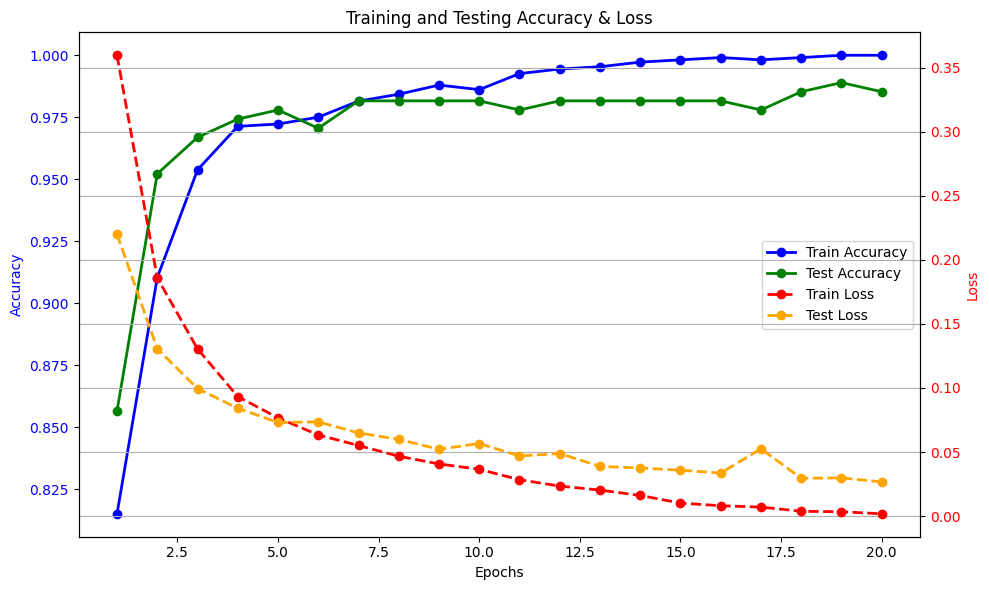

In [4]:
import matplotlib.pyplot as plt


train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(train_acc) + 1)

fig, ax1 = plt.subplots(figsize=(10, 6))

# ---- Left axis: Accuracy ----
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy', color='blue')
ax1.plot(epochs, train_acc, 'b-o', linewidth=2, markersize=6, label='Train Accuracy')
ax1.plot(epochs, val_acc, 'g-o', linewidth=2, markersize=6, label='Test Accuracy')
ax1.tick_params(axis='y', labelcolor='blue')

# ---- Right axis: Loss ----
ax2 = ax1.twinx()
ax2.set_ylabel('Loss', color='red')
ax2.plot(epochs, train_loss, 'r--o', linewidth=2, markersize=6, label='Train Loss')
ax2.plot(epochs, val_loss, color='orange', linestyle='--', marker='o', linewidth=2, markersize=6, label='Test Loss')
ax2.tick_params(axis='y', labelcolor='red')

# ---- Combined legends ----
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right')

plt.title('Training and Testing Accuracy & Loss')
plt.grid(True)
plt.tight_layout()
plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 968ms/step


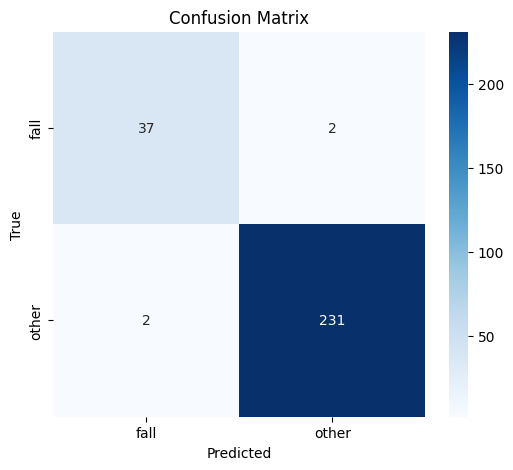

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Predictions
pred_probs = model.predict(test_generator, steps=validation_steps)
pred_classes = (pred_probs > 0.5).astype(int).flatten()
true_classes = test_generator.classes[:len(pred_classes)]

# Confusion matrix
cm = confusion_matrix(true_classes, pred_classes)

# Class names (définition de la variable 'labels')
labels = list(test_generator.class_indices.keys())

# Figure & Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

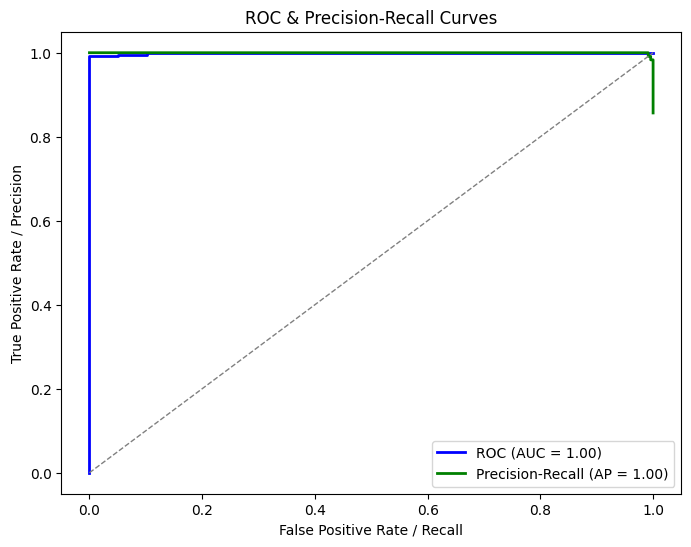

In [7]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# ------------------ Calculations ------------------
# ROC Curve and AUC
fpr, tpr, _ = roc_curve(true_classes, pred_probs)
roc_auc = auc(fpr, tpr)

# Precision-Recall Curve and Average Precision
precision, recall, _ = precision_recall_curve(true_classes, pred_probs)
ap = average_precision_score(true_classes, pred_probs)

# ------------------ Combined Figure ------------------
plt.figure(figsize=(8, 6))

# Plot ROC
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC (AUC = {roc_auc:.2f})')

# Plot Precision-Recall
plt.plot(recall, precision, color='green', lw=2, label=f'Precision-Recall (AP = {ap:.2f})')

# Diagonal line for ROC
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)

# Legends and titles
plt.xlabel('False Positive Rate / Recall')
plt.ylabel('True Positive Rate / Precision')
plt.title('ROC & Precision-Recall Curves')
plt.legend(loc="lower right")

# Save
plt.savefig("roc_and_pr_curves_combined.png", dpi=300, bbox_inches='tight')
plt.show()

[INFO] Using model already loaded in session.
Found 272 images belonging to 2 classes.
[INFO] Detected class mapping: {'fall': 0, 'other': 1} -> Legend labels: ['fall', 'other']
[INFO] Layer used for t-SNE embeddings: global_average_pooling1d


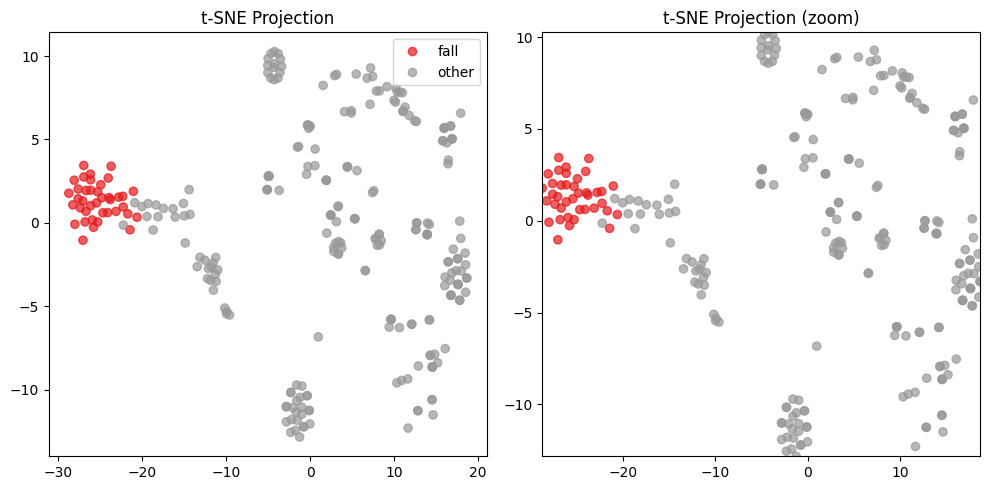

[INFO] t-SNE Embeddings image saved at 300 dpi -> tsne_embeddings_300dpi.png


In [9]:
# -*- coding: utf-8 -*-
# t-SNE on Embeddings: project the dataset image embeddings into 2D

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from sklearn.manifold import TSNE

# ----------------- CONFIG -----------------
IMG_SIZE = (224, 224)
target_layer_name = 'global_average_pooling1d'  # Before classification

# ----------------- Load the model -----------------
try:
    model
    print("[INFO] Using model already loaded in session.")
except NameError:
    model_path = "fall_detection_enhanced_model.keras"
    if os.path.exists(model_path):
        print(f"[INFO] Loading model from '{model_path}'...")
        model = tf.keras.models.load_model(model_path)
    else:
        raise RuntimeError("No model found in session and 'fall_detection_enhanced_model.keras' is missing.")

# ----------------- Create generator -----------------
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    '/tmp/fall_classification/test',
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# ----------------- Dynamic Class Mapping -----------------
# Get class names ordered by their numeric index (0, 1, ...)
class_labels = [k for k, v in sorted(test_generator.class_indices.items(), key=lambda item: item[1])]
print(f"[INFO] Detected class mapping: {test_generator.class_indices} -> Legend labels: {class_labels}")

# ----------------- Check embedding layer -----------------
try:
    layer = model.get_layer(target_layer_name)
except ValueError:
    raise RuntimeError(f"Layer '{target_layer_name}' not found in the model. Available layers: {', '.join([layer.name for layer in model.layers])}")
print(f"[INFO] Layer used for t-SNE embeddings: {target_layer_name}")

# ----------------- t-SNE embeddings function -----------------
def tsne_embeddings(model, test_generator, target_layer_name):
    embedding_model = Model(inputs=model.input, outputs=model.get_layer(target_layer_name).output)
    embeddings = embedding_model.predict(test_generator, verbose=0)
    labels = test_generator.classes
    tsne = TSNE(n_components=2, random_state=42)
    tsne_emb = tsne.fit_transform(embeddings)
    return tsne_emb, labels

tsne_emb, labels = tsne_embeddings(model, test_generator, target_layer_name)

# ----------------- t-SNE Visualization -----------------
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# t-SNE Projection
axes[0].set_title("t-SNE Projection")
scatter = axes[0].scatter(tsne_emb[:, 0], tsne_emb[:, 1], c=labels, cmap='Set1', alpha=0.7)
# CORRECTION HERE: using dynamic labels from class_indices
axes[0].legend(handles=scatter.legend_elements()[0], labels=class_labels)
axes[0].axis("on")

# t-SNE Projection (zoom)
axes[1].set_title("t-SNE Projection (zoom)")
axes[1].scatter(tsne_emb[:, 0], tsne_emb[:, 1], c=labels, cmap='Set1', alpha=0.7)
axes[1].set_xlim(tsne_emb[:, 0].min(), tsne_emb[:, 0].max())
axes[1].set_ylim(tsne_emb[:, 1].min(), tsne_emb[:, 1].max())
axes[1].axis("on")

plt.tight_layout()
plt.savefig("tsne_embeddings_300dpi.png", dpi=300, bbox_inches='tight')
plt.show()

print("[INFO] t-SNE Embeddings image saved at 300 dpi -> tsne_embeddings_300dpi.png")